FINAL EVALUATION: MWPM | CNN | Transformer (Scratch) | Hybrid (2‑Stage)

----------------------------------------------------------------------
Decoder                             Symmetric LER        Asymmetric LER      
----------------------------------------------------------------------
MWPM                                0.1500               0.1990              
CNN                                 0.1115               0.1515              
Transformer (Scratch)               0.0725               0.1305              
Hybrid (2‑Stage)                    —                    0.1265              
----------------------------------------------------------------------


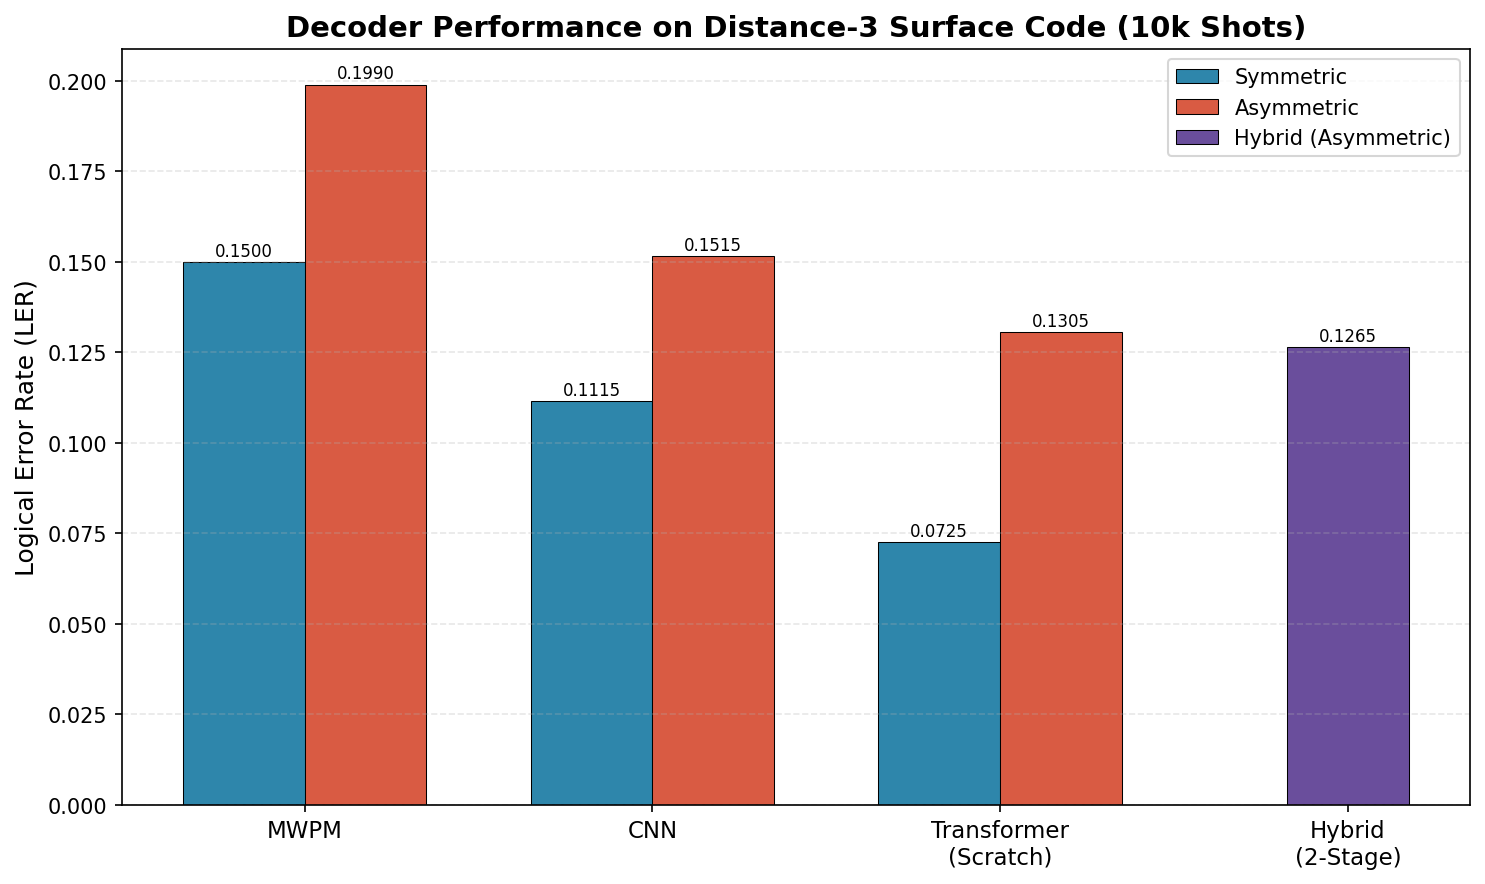


Plot saved as 'final_ler_hybrid_single.png'


In [ ]:
# -*- coding: utf-8 -*-
"""Final_Evaluation_v4.ipynb - Single bar for Hybrid"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("="*60)
print("FINAL EVALUATION: MWPM | CNN | Transformer (Scratch) | Hybrid (2‑Stage)")
print("="*60)

def load_if_exists(filename):
    if os.path.exists(filename):
        return pd.read_csv(filename)
    else:
        print(f"Warning: {filename} not found. Skipping.")
        return None

mwpm_sym = load_if_exists('mwpm_results_pretrain.csv')
mwpm_asym = load_if_exists('mwpm_results_finetune.csv')

trans_b_sym = load_if_exists('transformer_results_path_b.csv')
trans_b_asym = load_if_exists('transformer_results_path_b_asym.csv')
trans_c_asym = load_if_exists('transformer_results_path_c.csv')

cnn_b_sym = load_if_exists('cnn_results_path_b.csv')
cnn_c_asym = load_if_exists('cnn_results_path_c.csv')


def ler_from_df(df, pred_col):
    if df is None:
        return None
    return np.mean(df['GroundTruth'] != df[pred_col])

# MWPM
mwpm_sym_ler = ler_from_df(mwpm_sym, 'MWPM_Prediction')
mwpm_asym_ler = ler_from_df(mwpm_asym, 'MWPM_Prediction')

# CNN
cnn_sym_ler = ler_from_df(cnn_b_sym, 'CNN_B_Prediction')
cnn_asym_ler = ler_from_df(cnn_c_asym, 'CNN_C_Prediction')

# Transformer (scratch)
trans_sym_ler = ler_from_df(trans_b_sym, 'Path_B_Prediction')
trans_asym_ler = ler_from_df(trans_b_asym, 'Path_B_Asym_Prediction')

hybrid_asym_ler = ler_from_df(trans_c_asym, 'Path_C_Prediction')

print("\n" + "-"*70)
print(f"{'Decoder':<35} {'Symmetric LER':<20} {'Asymmetric LER':<20}")
print("-"*70)
print(f"{'MWPM':<35} {mwpm_sym_ler:<20.4f} {mwpm_asym_ler:<20.4f}")
print(f"{'CNN':<35} {cnn_sym_ler:<20.4f} {cnn_asym_ler:<20.4f}")
print(f"{'Transformer (Scratch)':<35} {trans_sym_ler:<20.4f} {trans_asym_ler:<20.4f}")
print(f"{'Hybrid (2‑Stage)':<35} {'—':<20} {hybrid_asym_ler:<20.4f}")
print("-"*70)


decoders = ['MWPM', 'CNN', 'Transformer\n(Scratch)', 'Hybrid\n(2‑Stage)']
# For each group, store sym and asym values (hybrid sym is None)
sym_vals = [mwpm_sym_ler, cnn_sym_ler, trans_sym_ler, None]
asym_vals = [mwpm_asym_ler, cnn_asym_ler, trans_asym_ler, hybrid_asym_ler]

x = np.arange(len(decoders))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)


for i in range(3):

    if sym_vals[i] is not None:
        ax.bar(x[i] - width/2, sym_vals[i], width, color='#2E86AB', edgecolor='black', linewidth=0.5,
               label='Symmetric' if i==0 else "")

    if asym_vals[i] is not None:
        ax.bar(x[i] + width/2, asym_vals[i], width, color='#D95B43', edgecolor='black', linewidth=0.5,
               label='Asymmetric' if i==0 else "")

if hybrid_asym_ler is not None:
    ax.bar(x[3], hybrid_asym_ler, width, color='#6A4E9C', edgecolor='black', linewidth=0.5,
           label='Hybrid (Asymmetric)')

ax.set_ylabel('Logical Error Rate (LER)', fontsize=12)
ax.set_title('Decoder Performance on Distance‑3 Surface Code (10k Shots)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(decoders, fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)


for i in range(3):
    if sym_vals[i] is not None:
        ax.annotate(f'{sym_vals[i]:.4f}', xy=(x[i] - width/2, sym_vals[i]),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
    if asym_vals[i] is not None:
        ax.annotate(f'{asym_vals[i]:.4f}', xy=(x[i] + width/2, asym_vals[i]),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
if hybrid_asym_ler is not None:
    ax.annotate(f'{hybrid_asym_ler:.4f}', xy=(x[3], hybrid_asym_ler),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('final_ler_hybrid_single.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'final_ler_hybrid_single.png'")